Warning message:
“`position_stack()` requires non-overlapping x intervals.”
Warning message:
“`position_stack()` requires non-overlapping x intervals.”
Warning message:
“Removed 2985 rows containing missing values or values outside the scale range (`geom_col()`).”
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
Warning message:
“Removed 5188 rows containing non-finite outside the scale range (`stat_smooth()`).”
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
Warning message:
“Removed 10 rows containing non-finite outside the scale range (`stat_smooth()`).”
Warning message:
“Removed 1 row containing missing values or values outside the scale range (`geom_smooth()`).”
Warning message:
“Removed 12 rows containing non-finite outside the scale range (`stat_boxplot()`).”
Warning message:
“Removed 25 rows containing non-finite outside the scale range (`stat_boxplot()`).”
Warning message:
“Removed 7 rows containing non-finite outs

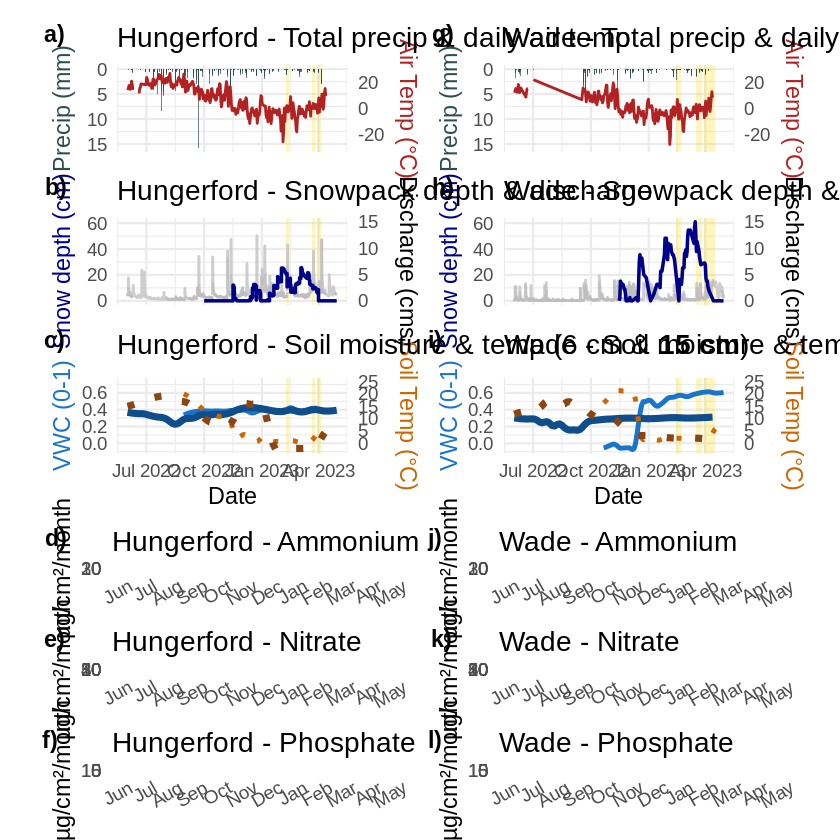

In [8]:
library(fs)

# Set directories
home_dir <- Sys.getenv("HOME")
repo_dir <- file.path(home_dir, "OneDrive/git-repos/LCBP-interannual-EMMAs")
source(file.path(repo_dir, "Functions/plot_compare_winter_soils.R"))
data_dir <- file.path(repo_dir, "Data/")

# Define Sampling Windows
hford_sampling_windows <- data.frame(
  start = as.POSIXct(c("2023-02-08 00:00", "2023-03-21 00:00", "2023-03-30 00:00"), tz = "UTC"),
  end   = as.POSIXct(c("2023-02-12 23:59", "2023-03-26 23:59", "2023-04-04 23:59"), tz = "UTC")
)

wade_sampling_windows <- data.frame(
  start = as.POSIXct(c("2023-02-14 00:00", "2023-03-18 00:00", "2023-03-30 00:00"), tz = "UTC"),
  end   = as.POSIXct(c("2023-02-20 23:59", "2023-03-26 23:59", "2023-04-15 23:59"), tz = "UTC")
)

# 1. RUN FOR BOTH SITES WITH 6 cm AND 15 cm SOIL FILES
combo_fig <- plot_compare_winter_soils(
  # Hungerford Variables
  site1_name        = "Hungerford",
  met_file1         = file.path(data_dir, "Met_data", "hungerford_2020-2024_met_2024-11-08.csv"),
  snow_file1        = file.path(data_dir, "Met_data", "enf-noaa-precip-WYW23.csv"),
  soil_file1_6cm    = file.path(data_dir, "SoilSensor_data", "Swanton_Faulkner/Middle_Teros_brief.csv"),
  soil_file1_15cm   = file.path(data_dir, "SoilSensor_data", "BREE_WY22-23/WY22-WY23_HW1_soil_temp_VWC_2025-02-22.csv"),
  q_file_1          = file.path(data_dir, "StreamSensor_data", "hb_q_chem_20211001-20230930.csv"),
  site1_samp_dates  = hford_sampling_windows,
  
  # Wade Variables 
  site2_name        = "Wade",
  met_file2         = file.path(data_dir, "Met_data", "wade_2020-2024_met_2024-11-08.csv"),
  snow_file2        = file.path(data_dir, "Met_data", "Wade_cocorahs-vt-fr-30-20221115-20250414-2.csv"),
  soil_file2_6cm    = file.path(data_dir, "SoilSensor_data", "Ranch_Brook/RanchBrook_TMS4_WY23_SML1_data.csv"),
  soil_file2_15cm   = file.path(data_dir, "SoilSensor_data", "BREE_WY22-23/WY22-WY23_WD5_soil_temp_VWC_2025-03-25.csv"),
  q_file_2          = file.path(data_dir, "StreamSensor_data", "wb_q_chem_20211001-20230930.csv"),
  site2_samp_dates  = wade_sampling_windows,
  
  # Shared Variables
  resin_file        = file.path(data_dir, "SoilNutrient_data", "Resin_timeseries_20250227.csv"),
  plot_range        = c("2022-06-01", "2023-04-30"),
  base_font_size    = 14
)

# View and save
print(combo_fig)
ggsave(file.path(repo_dir, "Output/Soil-nutrients/Sites_Comparison_Winter2023_Soils_Met.jpg"), 
       plot = combo_fig, width = 18, height = 16, dpi = 300)